In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
df = pd.read_csv('CareerGuidanceDataset.csv')

In [3]:
df.head()

,role,question,answer
0,Data Scientist,What does a Data Scientist do?,A Data Scientist extracts meaningful insights ...
1,Data Scientist,What are the main responsibilities of a Data S...,"Responsibilities include data cleaning, analyz..."
2,Data Scientist,What is the job description for a Data Scientist?,A Data Scientist is responsible for collecting...
3,Data Scientist,What skills are required to become a Data Scie...,Skills required include expertise in Python or...
4,Data Scientist,What are the essential skills for a successful...,A successful Data Scientist needs strong analy...


In [3]:
df.shape

(1620, 3)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   role      1620 non-null   object
 1   question  1620 non-null   object
 2   answer    1620 non-null   object
dtypes: object(3)
memory usage: 38.1+ KB


In [6]:
df.describe()

,role,question,answer
count,1620,1620,1620
unique,54,1620,1620
top,Data Scientist,What does a Data Scientist do?,A Data Scientist extracts meaningful insights ...
freq,30,1,1


In [7]:
df.isnull().sum()

role        0
question    0
answer      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
# Count unique vlaues in first column
df.iloc[:,0].unique()

array(['Data Scientist', 'Data Analyst', 'Software Engineer',
       'Machine Learning Engineer', 'AI Researcher', 'Business Analyst',
       'Product Manager (Entry-level)', 'QA Engineer', 'UX/UI Designer',
       'Digital Marketing Analyst', 'Automation Engineer',
       'Robotics Engineer', 'Game Developer',
       'Data Visualization Specialist', 'Mobile App Developer',
       'Site Reliability Engineer (SRE)', 'Salesforce Administrator',
       'Business Intelligence Analyst', 'Scrum Master (Junior level)',
       'E-commerce Specialist', 'Systems Administrator',
       'Technical Support Engineer', 'Web Developer',
       'Cloud Consultant (Junior level)', 'Cloud Database Engineer',
       'Application Support Analyst', 'AI Software Engineer',
       'Social Media Analyst', 'Content Strategist', 'SEO Specialist',
       'SEM (Search Engine Marketing) Specialist',
       'Digital Marketing Manager (Junior level)',
       'Advertising Manager (Junior level)',
       'Affiliate Mark

In [10]:
df.iloc[:,0].value_counts()

role
Data Scientist                                                 30
Sustainability Consultant (Entry-level)                        30
SEO Specialist                                                 30
SEM (Search Engine Marketing) Specialist                       30
Digital Marketing Manager (Junior level)                       30
Advertising Manager (Junior level)                             30
Affiliate Marketing Manager (Junior level)                     30
Market Development Manager (Junior level)                      30
Customer Relationship Manager                                  30
Product Owner (Entry-level)                                    30
UX Researcher                                                  30
Knowledge Manager (Junior level)                               30
Corporate Social Responsibility (CSR) Manager (Entry-level)    30
Media Buyer                                                    30
Data Analyst                                                   30
Trave

In [11]:
%matplotlib inline

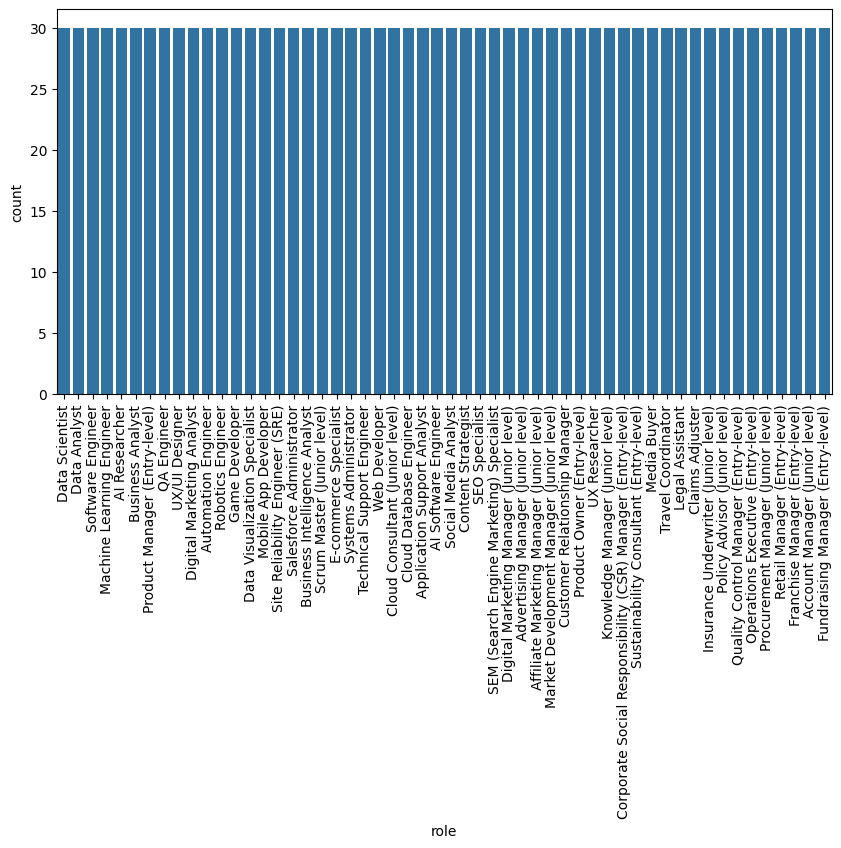

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(x=df.iloc[:,0])
plt.xticks(rotation=90)
plt.show()


In [13]:
df.columns

Index(['role', 'question', 'answer'], dtype='object')

# Data Preprocessing

In [14]:
import nltk
import string
nltk.download('stopwords')


from nltk.corpus import stopwords
english_stopwords = stopwords.words('english')

cleaned_col = []

for sent in df['question']:
  sent = sent.lower()
  for p in string.punctuation:
    sent = sent.replace(p, '')

  cleaned_col.append(' '.join([word for word in sent.split() if word not in english_stopwords]))
df['question'] = cleaned_col
    

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [15]:
df

,role,question,answer
0,Data Scientist,data scientist,A Data Scientist extracts meaningful insights ...
1,Data Scientist,main responsibilities data scientist,"Responsibilities include data cleaning, analyz..."
2,Data Scientist,job description data scientist,A Data Scientist is responsible for collecting...
3,Data Scientist,skills required become data scientist,Skills required include expertise in Python or...
4,Data Scientist,essential skills successful data scientist,A successful Data Scientist needs strong analy...
...,...,...,...
1615,Fundraising Manager (Entry-level),difficulties fundraising managers face jobs,Fundraising Managers face challenges such as m...
1616,Fundraising Manager (Entry-level),problems fundraising manager typically encounter,"Problems include managing tight budgets, ensur..."
1617,Fundraising Manager (Entry-level),start career fundraising manager,"Start by gaining experience in fundraising, ev..."
1618,Fundraising Manager (Entry-level),entrylevel requirements fundraising manager,Entry-level requirements typically include a b...


# Vectorization

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
vectorizer  = TfidfVectorizer()

X = vectorizer.fit_transform(df['question'])
y = encoder.fit_transform(df['role'])

In [18]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8116 stored elements and shape (1620, 163)>

In [19]:
X.toarray()

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.5268764]])

In [20]:
y

array([16, 16, 16, ..., 22, 22, 22])

In [21]:
X.shape

(1620, 163)

In [22]:
y.shape

(1620,)

# Splitting the data into train and test data

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model

In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**Predictions**

In [25]:
y_pred = model.predict(X_test)
y_pred

array([ 0, 44,  2, 43, 22, 25,  2, 45, 40, 18, 48, 12, 53, 16, 43,  5, 17,
       52, 45, 18,  6, 52, 52, 30, 32, 23, 25, 42, 46,  2,  1,  6, 11, 43,
       15,  0, 32, 21, 14, 30, 44, 10, 45, 42,  2, 25, 41, 38, 16, 18, 15,
        9, 17,  3, 31, 42, 46, 28, 29, 33, 48,  7,  8, 32, 10, 53,  4,  3,
       15, 37, 46, 31,  5,  7, 31, 37, 30,  3, 48, 24, 39, 47, 27, 18,  4,
       30, 52, 41, 51, 29, 26, 37, 31, 41,  9, 19, 10,  3, 52, 24, 49, 45,
        5, 15, 37, 11, 17, 23, 19, 39,  9,  9,  8, 10, 42, 48, 53, 21,  8,
       39, 49,  2,  1,  3, 46, 27, 48, 43, 36,  4, 49, 50, 23, 28, 50, 15,
       46,  7, 18, 43, 50, 29, 38,  0, 14, 36, 49,  9, 11, 44, 36,  8, 18,
       26, 44, 46, 13,  0, 45, 19,  8, 42, 39,  1, 37, 32, 19, 34, 35, 28,
       25, 12, 32,  8, 50, 44,  2, 21, 23, 22, 34, 17, 35, 50, 31, 10, 33,
       40, 17,  1, 42, 12, 26, 47, 34, 45, 13,  7, 35,  6, 40, 15, 23, 26,
       20, 14,  5, 52, 12, 19,  2, 14, 27, 23, 26, 47,  7, 23,  2, 17,  6,
       46, 39, 33, 11, 51

**Evaluation**

In [26]:
from sklearn.metrics import accuracy_score, classification_report
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         9
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00        10
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         8
          11       1.00      1.00      1.00         5
          12       1.00      1.00      1.00         5
          13       1.00      1.00      1.00         5
          14       1.00      1.00      1.00         6
          15       1.00      1.00      1.00         8
          16       1.00      1.00      1.00         3
          17       1.00

**Saving model and vectorizer**

In [27]:
import joblib

# Save model
joblib.dump(model, 'chatbot_model.pkl')

# Save vectorizer
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']